In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp
from sklearn.model_selection import cross_val_score,cross_validate, train_test_split, RandomizedSearchCV, GridSearchCV,StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder, OrdinalEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC


# TASK 6: Machine learning predicting breach

In [9]:

# # Encode categorical columns as integers
# lencoders = {}
# # Loop over the categorical features to encode them
# for col in df.select_dtypes(include=['object']).columns:
#     # Create a label encoder
#     lencoders[col] = LabelEncoder()
#     # Modify the data
#     df[col] = lencoders[col].fit_transform(df[col])


In [4]:
# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("AED4weeks.csv")

# -----------------------------
# Draw random sample (reproducible)
# -----------------------------
df

,ID,Age,Day,DayofWeek,Period,LoS,Breachornot,HRG,noofinvestigation,nooftreatment,noofpatients
0,P10000,4,1,Monday,0,197,non-breach,VB11Z,0,1,25
1,P10001,16,1,Monday,0,66,non-breach,VB11Z,0,1,26
2,P10002,1,1,Monday,0,233,non-breach,VB09Z,0,1,27
3,P10003,31,1,Monday,0,206,non-breach,VB03Z,6,1,26
4,P10004,59,1,Monday,0,232,non-breach,VB08Z,4,1,25
...,...,...,...,...,...,...,...,...,...,...,...
8776,P18776,18,28,Sunday,22,235,non-breach,VB08Z,4,1,49
8777,P18777,48,28,Sunday,22,93,non-breach,VB11Z,0,1,49
8778,P18778,57,28,Sunday,23,188,non-breach,VB09Z,0,1,47
8779,P18779,45,28,Sunday,23,215,non-breach,VB07Z,3,2,42


In [5]:
#Change Period and Day into object and encode Breachornot
df[['Period','Day']] = df[['Period','Day']].astype('object')
df["Breachornot"] = df["Breachornot"].map({
    "non-breach": 0,
    "breach": 1
})


In [6]:
#Change Period and Day into object 

X = df.drop(['Breachornot', 'LoS', 'ID'], axis=1)
y = df['Breachornot']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

## Preprocess for models using one hot encoder
preprocess_ohe = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

## Preprocess for models using label encoder
preprocess_tree = ColumnTransformer([
    ("cat", OrdinalEncoder(), cat_cols),
    ("num", StandardScaler(), num_cols)
])
df

,ID,Age,Day,DayofWeek,Period,LoS,Breachornot,HRG,noofinvestigation,nooftreatment,noofpatients
0,P10000,4,1,Monday,0,197,0,VB11Z,0,1,25
1,P10001,16,1,Monday,0,66,0,VB11Z,0,1,26
2,P10002,1,1,Monday,0,233,0,VB09Z,0,1,27
3,P10003,31,1,Monday,0,206,0,VB03Z,6,1,26
4,P10004,59,1,Monday,0,232,0,VB08Z,4,1,25
...,...,...,...,...,...,...,...,...,...,...,...
8776,P18776,18,28,Sunday,22,235,0,VB08Z,4,1,49
8777,P18777,48,28,Sunday,22,93,0,VB11Z,0,1,49
8778,P18778,57,28,Sunday,23,188,0,VB09Z,0,1,47
8779,P18779,45,28,Sunday,23,215,0,VB07Z,3,2,42


In [7]:
np.random.seed(42)
# ### Training and Test set split 
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.1, stratify = y,random_state=42)

### Hyper-Parameters Optimization of RF using Random Search

pipe_rf = Pipeline([
    ("preprocess", preprocess_tree),
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])


param_dist = {
    "rf__n_estimators": sp.randint(10,110),
    "rf__criterion": ["gini", "entropy"],
    "rf__max_features": sp.uniform(0.1, 0.9),
    "rf__min_samples_split": sp.uniform(0.01, 0.49)
}
combs = 50
rf = RandomizedSearchCV(pipe_rf, param_dist,scoring = 'f1', n_iter = combs,cv=10,random_state=42)
rf.fit(x_train,y_train)
print('RF best CV:',rf.best_score_,)
print('RF score on test set:', rf.score(x_test,y_test))

### Hyper-Parameters Optimization of LogisticRegression using Grid Search

pipe_lr = Pipeline([
    ("preprocess", preprocess_ohe),
    ("smote", SMOTE(random_state=42)),
    ("logit", LogisticRegression(max_iter=1000, random_state=42))
])


param_grid = {
    "logit__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "logit__penalty": ["l1", "l2"],
    "logit__solver": ["liblinear"],
    "logit__class_weight": [None, "balanced"]
}
lr = GridSearchCV(
    pipe_lr,
    param_grid=param_grid,
    scoring="f1",
    cv=10,
    n_jobs=-1
)
lr.fit(x_train,y_train)
print('LR best CV:', lr.best_score_)
print('LR score on the test set:', lr.score(x_test,y_test))

### Hyper-Parameters Optimization of GradientBoosting using Grid Search

pipe_gb = Pipeline([
    ("preprocess", preprocess_tree),
    ("smote", SMOTE(random_state=42)),
    ("gb", GradientBoostingClassifier(random_state=42))
])


param_gb = {
    "gb__n_estimators": [100, 200],
    "gb__learning_rate": [0.05, 0.1],
    "gb__max_depth": [3, 5]
}

gb_search = GridSearchCV(
    pipe_gb,
    param_grid=param_gb,
    scoring="f1",
    cv=10,
    n_jobs=-1
)

gb_search.fit(x_train, y_train)
print("GB best CV:", gb_search.best_score_)
print("GB score on test set:", gb_search.score(x_test,y_test))

### Hyper-Parameters Optimization of DecisionTree using Grid Search

pipe_dt = Pipeline([
    ("preprocess", preprocess_tree),
    ("smote", SMOTE(random_state=42)),
    ("dt", DecisionTreeClassifier(random_state=42))
])


param_dt = {
    "dt__max_depth": [3, 5, 8, 12, None],
    "dt__min_samples_split": [2, 5, 10],
    "dt__min_samples_leaf": [1, 5, 10]
}

dt_search = GridSearchCV(
    pipe_dt,
    param_grid=param_dt,
    scoring="f1",
    cv=10,
    n_jobs=-1
)

dt_search.fit(x_train, y_train)
print("DT best CV:", dt_search.best_score_)
print("DT score on the test set:", dt_search.score(x_test,y_test))

### Hyper-Parameters Optimization of SVM using Grid Search

pipe_svm = Pipeline([
    ("preprocess", preprocess_ohe),
    ("smote", SMOTE(random_state=42)),
    ("svm", SVC(probability=True, random_state=42))
])


param_svm = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["rbf"],
    "svm__gamma": ["scale", 0.01, 0.1]
}

svm_search = GridSearchCV(
    pipe_svm,
    param_grid=param_svm,
    scoring="f1",
    cv=10,
    n_jobs=-1
)

svm_search.fit(x_train, y_train)
print("SVM best CV:", svm_search.best_score_)
print("SVM score on the test set:",  svm_search.score(x_test,y_test))


RF best CV: 0.2462437142543724
RF score on test set: 0.3076923076923077
LR best CV: 0.1622112456779303
LR score on the test set: 0.18867924528301885
GB best CV: 0.2754644213395744
GB score on test set: 0.2978723404255319
DT best CV: 0.20241644676187623
DT score on the test set: 0.2898550724637681
SVM best CV: 0.21430983324484645
SVM score on the test set: 0.2191780821917808


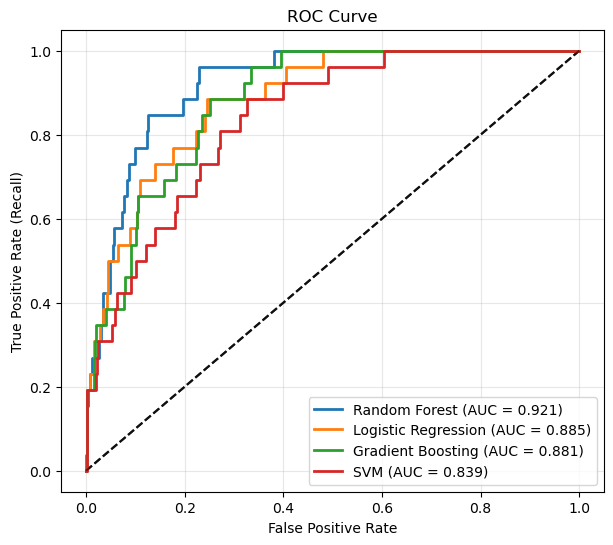

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_curve(model, X_test, y_test, label=None):
    """
    Plot ROC curve for a fitted model.
    """

    # Get probability scores
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    # Plot
    plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(alpha=0.3)

    return auc
plt.figure(figsize=(7, 6))

plot_roc_curve(rf.best_estimator_, x_test, y_test, label="Random Forest")
plot_roc_curve(lr.best_estimator_, x_test, y_test, label="Logistic Regression")
plot_roc_curve(gb_search.best_estimator_, x_test, y_test, label="Gradient Boosting")
plot_roc_curve(svm_search.best_estimator_, x_test, y_test, label="SVM")

plt.show()


In [14]:

def evaluate_models_cv(models, X, y, cv=5, scoring=None):
    """
    models: dict of {model_name: pipeline}
    X, y: full training data
    cv: number of folds
    scoring: list or dict of metrics
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    results = []

    for name, model in models.items():
        cv_results = cross_validate(
            model,
            X,
            y,
            cv=skf,
            scoring=scoring,
            return_train_score=False
        )

        summary = {
            "Model": name
        }

        for metric in cv_results:
            if metric.startswith("test_"):
                summary[metric.replace("test_", "")] = (
                    np.mean(cv_results[metric]),
                    np.std(cv_results[metric])
                )

        results.append(summary)

    return pd.DataFrame(results)


In [15]:
models_optimized = {
    "Logistic Regression": lr.best_estimator_,
    "Random Forest": rf.best_estimator_,
    "SVM": svm_search.best_estimator_,
    "Gradient Boosting": gb_search.best_estimator_,
    "Decision Tree": dt_search.best_estimator_
}
scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision"
}
cv_results = evaluate_models_cv(models_optimized, x_train, y_train, cv=10, scoring=(['roc_auc','precision','recall','f1']))
print(pd.DataFrame(round(cv_results,4)))
# Best model is between LR, RF, and SVM. However, the F1 score of RF is noticeably higher -> final model is RF

                 Model                                    roc_auc  \
0  Logistic Regression  (0.8242469844114131, 0.04554252371379587)   
1        Random Forest  (0.8185339334687386, 0.04153593016287904)   
2                  SVM  (0.7885970831853893, 0.04238472279491591)   
3    Gradient Boosting  (0.8133249765078177, 0.04152233963319778)   
4        Decision Tree   (0.6786385954760917, 0.0611174937817281)   

                                     precision  \
0  (0.08960850829238733, 0.013760465487477929)   
1     (0.2243921964703198, 0.0689027817702922)   
2   (0.14381153722961443, 0.04672889185622957)   
3     (0.3149134199134199, 0.1337760669167738)   
4   (0.18527666011624636, 0.06190009811015663)   

                                       recall  \
0   (0.6826086956521739, 0.11785335798634608)   
1  (0.33115942028985507, 0.12332899053986633)   
2   (0.2967391304347826, 0.10582191489836983)   
3  (0.18496376811594203, 0.06523475010527785)   
4   (0.2498188405797102, 0.090200110387

In [10]:
best_svm = svm_search.best_estimator_
best_rf = rf.best_estimator_
best_lr = lr.best_estimator_
best_gb = gb_search.best_estimator_
best_dt = dt_search.best_estimator_
### Confusion matrix
y_pred_rf = best_rf.predict(x_test)
cm_rf = confusion_matrix(y_test,y_pred_rf,labels = [0,1])
print('RF confusion matrix')
print(cm_rf)

y_pred_svm = best_svm.predict(x_test)
cm_svm = confusion_matrix(y_test,y_pred_svm,labels = [0,1])
print('SVM confusion matrix')
print(cm_svm)

y_pred_lr = best_lr.predict(x_test)
cm_lr = confusion_matrix(y_test,y_pred_lr,labels = [0,1])
print('LR confusion matrix')
print(cm_lr)

y_pred_gb = best_gb.predict(x_test)
cm_gb = confusion_matrix(y_test,y_pred_gb,labels = [0,1])
print('GB confusion matrix')
print(cm_gb)

y_pred_dt = best_dt.predict(x_test)
cm_dt= confusion_matrix(y_test,y_pred_dt,labels = [0,1])
print('DT confusion matrix')
print(cm_dt)

# #print(classification_report(y_test, y_pred))
# fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# plt.figure(figsize=(6,6))
# plt.plot(fpr, tpr, label="ROC curve")
# plt.plot([0,1], [0,1], "k--", label="Random")

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate (Recall)")
# plt.title("ROC Curve")
# plt.legend()
# plt.show()

# target_tpr = 0.97
# idx = (tpr >= target_tpr).argmax()
# threshold = thresholds[idx]
# plt.figure(figsize=(6,6))
# plt.plot(fpr, tpr, label="ROC curve")
# plt.scatter(fpr[idx], tpr[idx], color="red", zorder=5,
#             label=f"Chosen threshold = {threshold:.3f}")

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate (Recall)")
# plt.title("ROC Curve with Selected Operating Point")
# plt.legend()
# plt.show()


# #Change the threshold
# threshold = 0.5381471405094274
# y_pred_thresh = (y_prob >= threshold).astype(int)

# confusion_matrix(y_test, y_pred_thresh)

RF confusion matrix
[[824  29]
 [ 16  10]]
SVM confusion matrix
[[814  39]
 [ 18   8]]
LR confusion matrix
[[687 166]
 [  6  20]]
GB confusion matrix
[[839  14]
 [ 19   7]]
DT confusion matrix
[[820  33]
 [ 16  10]]


In [11]:
best_rf

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat', OrdinalEncoder(),
                                                  ['Day', 'DayofWeek', 'Period',
                                                   'HRG']),
                                                 ('num', StandardScaler(),
                                                  ['Age', 'noofinvestigation',
                                                   'nooftreatment',
                                                   'noofpatients'])])),
                ('smote', SMOTE(random_state=42)),
                ('rf',
                 RandomForestClassifier(criterion='entropy',
                                        max_features=0.6504878444394528,
                                        min_samples_split=0.01346248955766153,
                                        n_estimators=98, random_state=42))])

In [45]:
#threshold tuning
def cv_threshold_tuning(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    thresholds = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)

        # Probabilities
        if hasattr(model, "predict_proba"):
            y_val_prob = model.predict_proba(X_val)[:, 1]
        else:
            y_val_prob = model.decision_function(X_val)

        fpr, tpr, thr = roc_curve(y_val, y_val_prob)
        best_thr = thr[np.argmax(tpr - fpr)]  # Youden’s J
        thresholds.append(best_thr)

    return np.mean(thresholds)
#tuning
best_svm = svm_search.best_estimator_
best_rf = rf.best_estimator_
best_lr = lr.best_estimator_
rf_threshold = cv_threshold_tuning(best_rf, x_train, y_train)
lr_threshold = cv_threshold_tuning(best_lr, x_train, y_train)
svm_threshold = cv_threshold_tuning(best_svm, x_train, y_train)

print("RF CV threshold:", rf_threshold)
print("LR CV threshold:", lr_threshold)
print("SVM CV threshold:", svm_threshold)

y_prob_rf = best_rf.predict_proba(x_test)[:, 1]
y_pred_rf = (y_prob_rf >= rf_threshold).astype(int)

print("Random Forest Test Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

y_prob_lr = best_lr.predict_proba(x_test)[:, 1]
y_pred_lr = (y_prob_lr >= lr_threshold).astype(int)

print("Logistic Regression Test Results")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

y_prob_svm = best_svm.predict_proba(x_test)[:, 1]
y_pred_svm = (y_prob_lr >= svm_threshold).astype(int)

print("SVM Test Results")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))


RF CV threshold: 0.16466834417661833
LR CV threshold: 0.39631752240314283
SVM CV threshold: 0.27430235781750845
Random Forest Test Results
[[504 349]
 [  0  26]]
              precision    recall  f1-score   support

           0       1.00      0.59      0.74       853
           1       0.07      1.00      0.13        26

    accuracy                           0.60       879
   macro avg       0.53      0.80      0.44       879
weighted avg       0.97      0.60      0.72       879

ROC-AUC: 0.8993146361258906
Logistic Regression Test Results
[[608 245]
 [  2  24]]
              precision    recall  f1-score   support

           0       1.00      0.71      0.83       853
           1       0.09      0.92      0.16        26

    accuracy                           0.72       879
   macro avg       0.54      0.82      0.50       879
weighted avg       0.97      0.72      0.81       879

ROC-AUC: 0.8930471638560735
SVM Test Results
[[521 332]
 [  1  25]]
              precision    recal

             feature  importance
0  noofinvestigation    0.574727
1             Period    0.156000
2                Age    0.130674
3      nooftreatment    0.035841
4          DayofWeek    0.032260
5                Day    0.030083
6       noofpatients    0.025976
7                HRG    0.014440


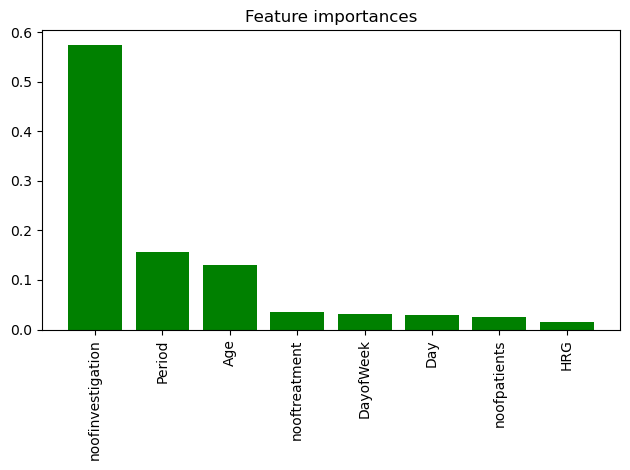

In [16]:
# Feature Importance
rf_model = best_rf.named_steps["rf"]
importances = rf_model.feature_importances_
indices = np.argsort(-importances)
df_imp = pd.DataFrame(dict(feature = x_train.columns[indices],importance = importances[indices]))
print(df_imp)

# Plot the feature importances of the forest
plt.figure()
plt.title("Feature importances")
plt.bar(range(len(importances)), df_imp['importance'], color="green", align="center")
plt.xticks(range(len(importances)), df_imp['feature'], rotation=90)
plt.tight_layout()
plt.savefig("chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
## MLP Regression 
np.random.seed(42)
x_train1, x_test1, y_train1, y_test1 = train_test_split(df.drop(['Breachornot','LoS','ID'],axis=1),df['LoS'],test_size = 0.1, random_state=42)
y_train1_log = np.log1p(y_train1)
y_test1_log = np.log1p(y_test1)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        max_iter=30000,
        random_state=42
    ))
])

pipe_param_dist = dict(mlp__hidden_layer_sizes = sp. randint (5,20, (1,1)),
                       mlp__solver = ['lbfgs', 'adam'])

random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=pipe_param_dist,
                                   n_iter=20, 
                                   cv=5, 
                                   n_jobs = 2,
                                   random_state=42)
random_search.fit(x_train1,y_train1_log)
print("Best parameters:", random_search.best_params_)
print("Mean CV R²:", random_search.best_score_)
print("Test R²:", random_search.score(x_test1, y_test1_log))

Best parameters: {'mlp__hidden_layer_sizes': array([ 7, 17]), 'mlp__solver': 'lbfgs'}
Mean CV R²: 0.3951203541882825
Test R²: 0.3993004359808452


In [33]:
# ### Confusion matrix
# y_pred = dt_search.predict(x_test)
# y_prob = dt_search.predict_proba(x_test)[:, 1]
# cm = confusion_matrix(y_test,y_pred,labels = [0,1])
# print(cm)
# #print(classification_report(y_test, y_pred))
# fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# plt.figure(figsize=(6,6))
# plt.plot(fpr, tpr, label="ROC curve")
# plt.plot([0,1], [0,1], "k--", label="Random")

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate (Recall)")
# plt.title("ROC Curve")
# plt.legend()
# plt.show()

# target_tpr = 0.97
# idx = (tpr >= target_tpr).argmax()
# threshold = thresholds[idx]
# plt.figure(figsize=(6,6))
# plt.plot(fpr, tpr, label="ROC curve")
# plt.scatter(fpr[idx], tpr[idx], color="red", zorder=5,
#             label=f"Chosen threshold = {threshold:.3f}")

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate (Recall)")
# plt.title("ROC Curve with Selected Operating Point")
# plt.legend()
# plt.show()


# #Change the threshold
# threshold = 0.5381471405094274
# y_pred_thresh = (y_prob >= threshold).astype(int)

# confusion_matrix(y_test, y_pred_thresh)

In [32]:
# from sklearn.linear_model import LogisticRegression
# logit = LogisticRegression(max_iter=1000)
# logit.fit(x_train, y_train)
# logit.score(x_test,y_test)
# y_pred_logit = logit.predict(x_test)
# conf_mat = confusion_matrix(y_test, y_pred_logit)
# conf_mat

# y_prob_logit = logit.predict_proba(x_test)[:, 1]
# plt.hist(y_prob_logit[y_test == 0], alpha=0.6, label="Breach")
# plt.hist(y_prob_logit[y_test == 1], alpha=0.6, label="Non-breach")
# plt.legend()
# plt.xlabel("Predicted probability of non-breach")
# plt.show()
# threshold = 0.98
# y_pred_thresh = (y_prob_logit >= threshold).astype(int)

# confusion_matrix(y_test, y_pred_thresh)

# best_lr = lr.best_estimator_
# y_pred_logit = best_lr.predict(x_test)
# y_prob_logit = logit.predict_proba(x_test)[:, 1]
# print(confusion_matrix(y_test, y_pred_logit))
# threshold = 0.97

# y_pred_thresh = (y_prob_logit >= threshold).astype(int)

# print(confusion_matrix(y_test, y_pred_thresh))